In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import sklearn



In [54]:
import spacy

nlp = spacy.load("en_core_web_sm")
print("spaCy model loaded")

spaCy model loaded


In [55]:
reviews = []
labels = []

with open("train.ft.txt", encoding="utf-8") as f:
    for line in f:
        labels.append(1 if "__label__2" in line else 0)

        review = line.replace("__label__1", "")
        review = review.replace("__label__2", "")
        reviews.append(review.strip())

df = pd.DataFrame({
    "Review": reviews,
    "Sentiment": labels
})

In [56]:
df.head()

,Review,Sentiment
0,Stuning even for the non-gamer: This sound tra...,1
1,The best soundtrack ever to anything.: I'm rea...,1
2,Amazing!: This soundtrack is my favorite music...,1
3,Excellent Soundtrack: I truly like this soundt...,1
4,"Remember, Pull Your Jaw Off The Floor After He...",1


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600000 entries, 0 to 3599999
Data columns (total 2 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   Review     object
 1   Sentiment  int64 
dtypes: int64(1), object(1)
memory usage: 54.9+ MB


In [58]:
df = df.sample(50000, random_state=42)

In [59]:
df['Sentiment'].value_counts()

Sentiment
1    25039
0    24961
Name: count, dtype: int64

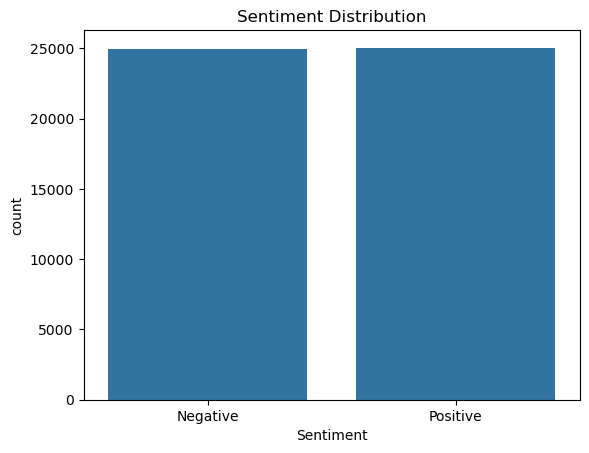

In [60]:
sns.countplot(x='Sentiment', data=df)

plt.xticks([0,1], ['Negative','Positive'])

plt.title("Sentiment Distribution")

plt.show()

In [61]:
df['review_length'] = df['Review'].apply(len)

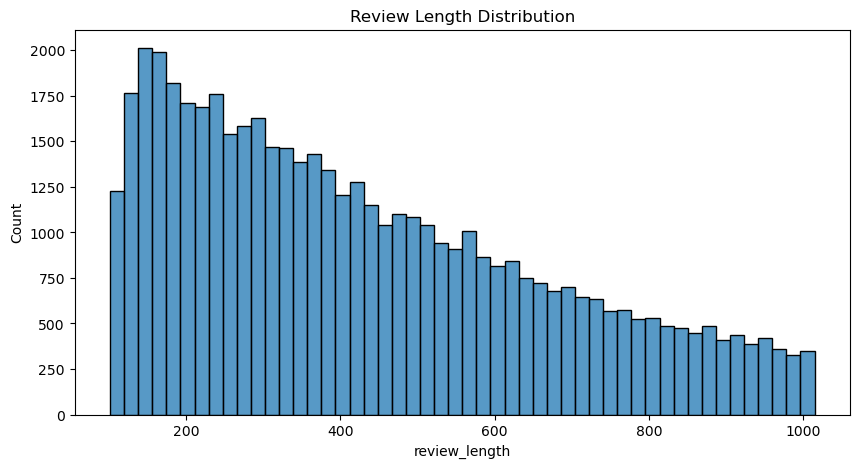

In [62]:
plt.figure(figsize=(10,5))

sns.histplot(df['review_length'], bins=50)

plt.title("Review Length Distribution")

plt.show()

In [63]:
df.groupby('Sentiment')['review_length'].mean()

Sentiment
0    449.399022
1    414.575582
Name: review_length, dtype: float64

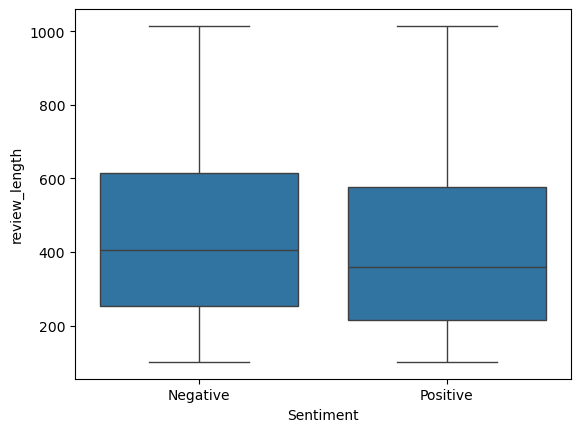

In [64]:
sns.boxplot(
    x='Sentiment',
    y='review_length',
    data=df
)

plt.xticks([0,1], ['Negative','Positive'])

plt.show()

In [65]:
import spacy

nlp = spacy.load("en_core_web_sm")

In [66]:
negations = {"not", "no", "never", "nor"}

def preprocess(text):

    doc = nlp(str(text).lower())

    tokens = []

    for token in doc:

        if token.is_punct:
            continue

        if token.text in negations:
            tokens.append(token.text)

        elif not token.is_stop:
            tokens.append(token.lemma_)

    return " ".join(tokens)

In [67]:
from tqdm import tqdm

tqdm.pandas()

df['clean_review'] = df['Review'].progress_apply(preprocess)

100%|██████████| 50000/50000 [18:37<00:00, 44.76it/s]  


In [68]:
df[['Review','clean_review']].head()

,Review,clean_review
2079998,Expensive Junk: This product consists of a pie...,expensive junk product consist piece thin flex...
1443106,"Toast too dark: Even on the lowest setting, th...",toast dark low setting toast dark liking light...
3463669,Excellent imagery...dumbed down story: I enjoy...,excellent imagery dumbe story enjoy disc video...
2914699,Are we pretending everyone is married?: The au...,pretend marry author pretend parent die nor di...
1603231,Not worth your time: Might as well just use a ...,not worth time use knife product hold find use...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review'])
  
y = df['Sentiment']

In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [71]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [72]:
y_pred = model.predict(X_test)

In [73]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8305


In [74]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83      5001
           1       0.83      0.83      0.83      4999

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



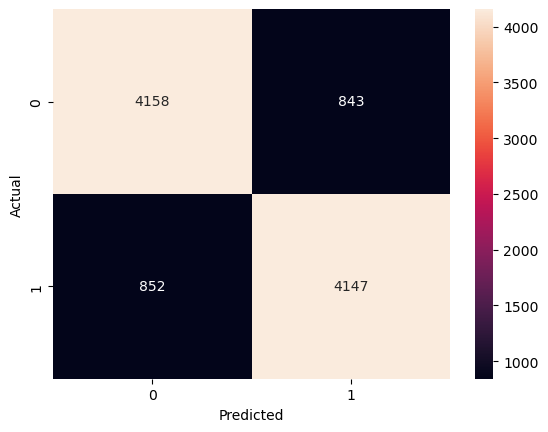

In [75]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [76]:
import pickle

pickle.dump(
    model,
    open("sentiment_model.pkl","wb")
)

pickle.dump(
    tfidf,
    open("vectorizer.pkl","wb")
)

In [77]:
review = "Amazing quality and fast delivery"

clean_review = preprocess(review)

vector = tfidf.transform([clean_review])

prediction = model.predict(vector)

if prediction[0] == 1:
    print("Positive Review")
else:
    print("Negative Review")

Positive Review


In [ ]:
def predict_sentiment(review):

    clean_review = preprocess(review)
    vector = tfidf.transform([clean_review])
    prediction = model.predict(vector)

    if prediction[0] == 1:
        return "Positive Review 😊"
    else:
        return "Negative Review 😞"

In [80]:
user_review = input("Enter Product Review: ")

result = predict_sentiment(user_review)

print("\nPrediction:", result)


Prediction: Positive


In [81]:
import streamlit as st

st.title("Amazon Product Review Analyzer")

review = st.text_area("Enter Product Review")

if st.button("Predict Sentiment"):

    result = predict_sentiment(review)

    st.subheader(result)

2026-06-11 13:37:39.907 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 13:37:41.454 
  command:

    streamlit run c:\Users\Som\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-11 13:37:41.456 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 13:37:41.458 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 13:37:41.459 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 13:37:41.462 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 13:37:41.466 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-11 13:37:41.467 Session state does not fu